In [8]:
import os
import glob
import pandas as pd
from pandas.api.types import is_numeric_dtype

# --- CONFIGURATION ---
BASE_DIR = (
    "/home/local/ASUAD/jrtandel/transchema/autopipeline-benchmarks/github-pipelines"
)
OUTPUT_CSV = "cases_summary.csv"
# ----------------------


def drop_unnamed_cols(df):
    to_drop = [c for c in df.columns if c.strip() == "" or c.startswith("Unnamed")]
    return df.drop(columns=to_drop)


def parse_ids(case_name):
    core = case_name[len("length") :]
    len_id_str, tgt_id_str = core.split("_", 1)
    return int(len_id_str), int(tgt_id_str)


def analyze_case(case_path):
    src_files = sorted(glob.glob(os.path.join(case_path, "test_*.csv")))
    num_src_tables = len(src_files)

    # lists to collect per-table counts
    numeric_counts = []
    categorical_counts = []

    for fp in src_files:
        df = pd.read_csv(fp, low_memory=False)
        df = drop_unnamed_cols(df)

        num_cols = sum(is_numeric_dtype(df[col]) for col in df.columns)
        cat_cols = len(df.columns) - num_cols

        numeric_counts.append(num_cols)
        categorical_counts.append(cat_cols)

    # compute totals
    total_num = sum(numeric_counts)
    total_cat = sum(categorical_counts)

    # compute avg/min/max (avoid division by zero)
    if num_src_tables > 0:
        avg_num = total_num / num_src_tables
        min_num = min(numeric_counts)
        max_num = max(numeric_counts)

        avg_cat = total_cat / num_src_tables
        min_cat = min(categorical_counts)
        max_cat = max(categorical_counts)
    else:
        avg_num = min_num = max_num = 0
        avg_cat = min_cat = max_cat = 0

    # target table
    tgt_fp = os.path.join(case_path, "target.csv")
    if not os.path.isfile(tgt_fp):
        raise FileNotFoundError(f"Missing target.csv in {case_path}")
    df_tgt = pd.read_csv(tgt_fp, low_memory=False)
    df_tgt = drop_unnamed_cols(df_tgt)
    tgt_num = sum(is_numeric_dtype(df_tgt[col]) for col in df_tgt.columns)
    tgt_cat = len(df_tgt.columns) - tgt_num

    return {
        "num_src_tables": num_src_tables,
        "src_numeric_total": total_num,
        "src_categorical_total": total_cat,
        "src_numeric_avg": avg_num,
        "src_numeric_min": min_num,
        "src_numeric_max": max_num,
        "src_categorical_avg": avg_cat,
        "src_categorical_min": min_cat,
        "src_categorical_max": max_cat,
        "tgt_numeric": tgt_num,
        "tgt_categorical": tgt_cat,
    }


def main():
    pattern = os.path.join(BASE_DIR, "length*_*")
    case_dirs = sorted(d for d in glob.glob(pattern) if os.path.isdir(d))
    records = []

    for case in case_dirs:
        case_name = os.path.basename(case)
        try:
            length_id, target_id = parse_ids(case_name)
            stats = analyze_case(case)
        except Exception as e:
            print(f"  ❗ Skipping {case_name}: {e}")
            continue

        record = {
            "case": case_name,
            "length_id": length_id,
            "target_id": target_id,
            **stats,
        }
        records.append(record)

    # build DataFrame & save
    cols = [
        "case",
        "length_id",
        "target_id",
        "num_src_tables",
        "src_numeric_total",
        "src_categorical_total",
        "src_numeric_avg",
        "src_numeric_min",
        "src_numeric_max",
        "src_categorical_avg",
        "src_categorical_min",
        "src_categorical_max",
        "tgt_numeric",
        "tgt_categorical",
    ]
    df_summary = pd.DataFrame(records, columns=cols)
    df_summary.sort_values(["length_id", "target_id"], inplace=True)
    print(df_summary.to_string(index=False))
    df_summary.to_csv(OUTPUT_CSV, index=False)
    print(f"\nSummary written to {OUTPUT_CSV}")

In [9]:
main()

       case  length_id  target_id  num_src_tables  src_numeric_total  src_categorical_total  src_numeric_avg  src_numeric_min  src_numeric_max  src_categorical_avg  src_categorical_min  src_categorical_max  tgt_numeric  tgt_categorical
  length1_0          1          0               1                  2                      3         2.000000                2                2             3.000000                    3                    3            1                1
  length1_1          1          1               2                  6                      6         3.000000                3                3             3.000000                    2                    4            6                5
  length1_2          1          2               2                 20                     10        10.000000               10               10             5.000000                    5                    5           10                5
  length1_3          1          3               1       

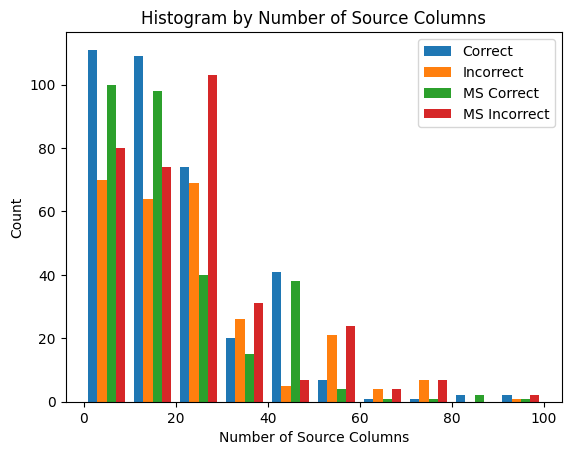

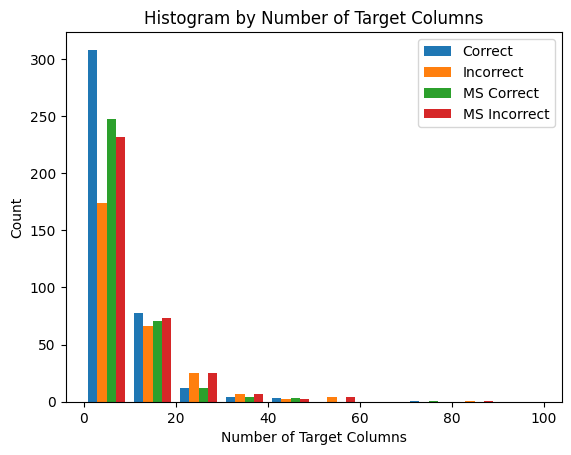

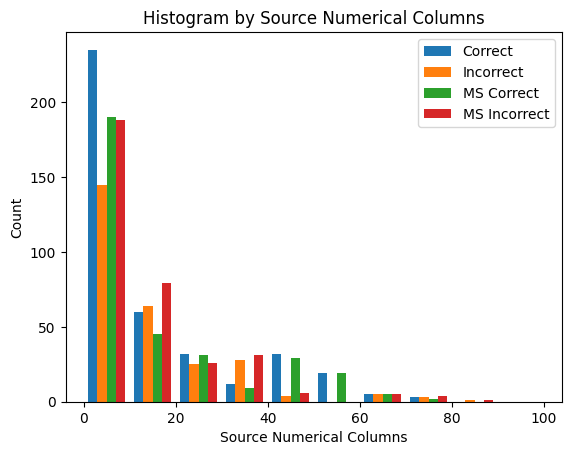

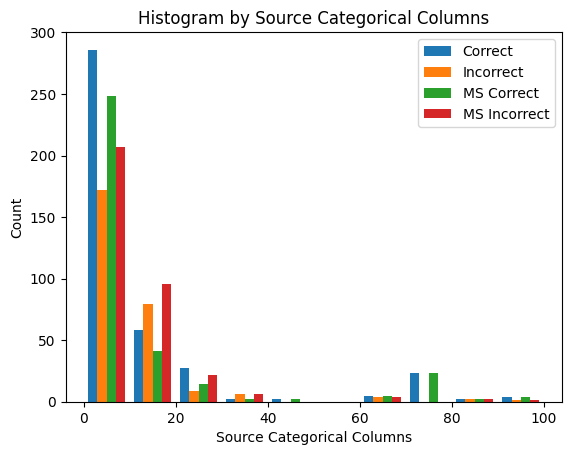

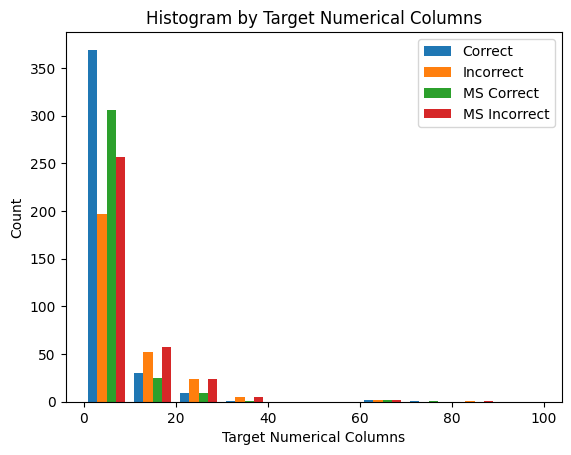

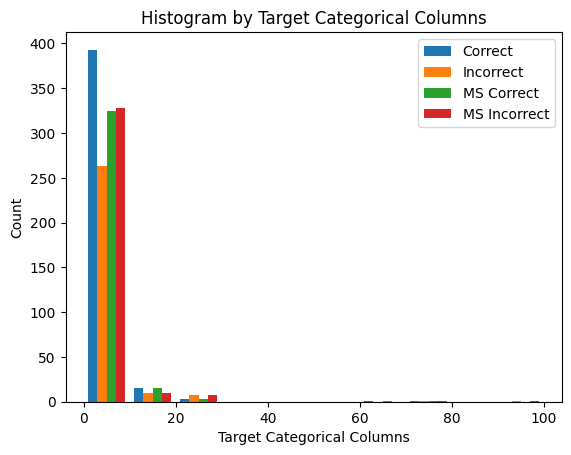

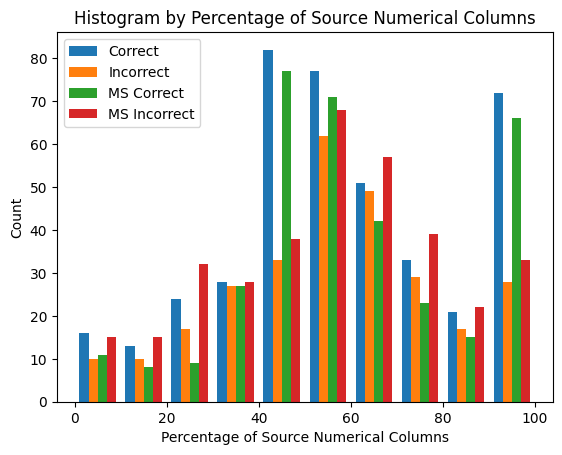

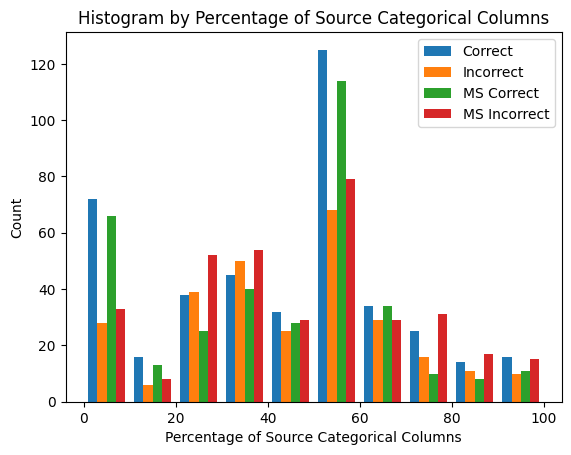

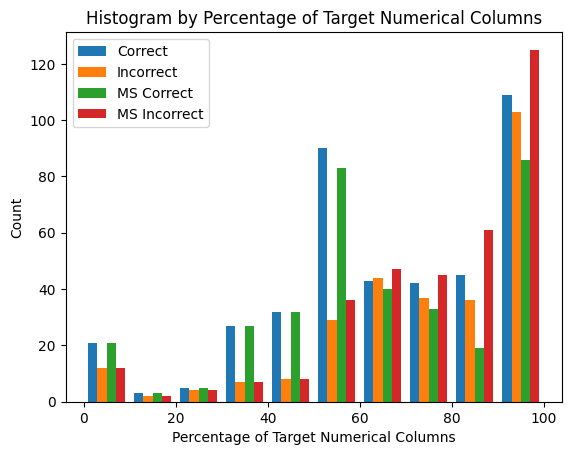

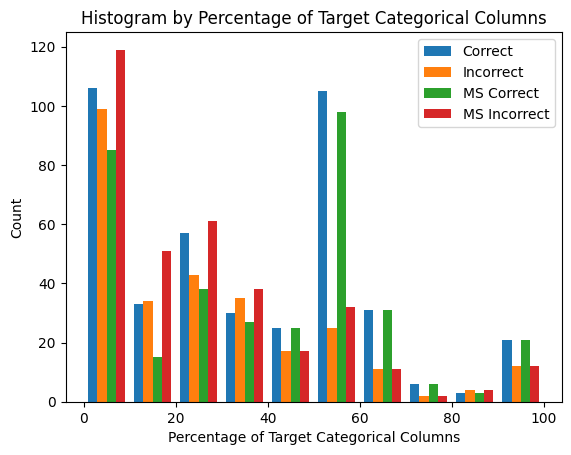

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the updated CSV
csv_path = "/home/local/ASUAD/jrtandel/transchema/Few Shot Analysis - AutoPipeline Data Analysis.csv"
df = pd.read_csv(csv_path)

# Compute combined and percentage columns
df["num_src_cols"] = df["src_numeric_total"] + df["src_categorical_total"]
df["num_tgt_cols"] = df["tgt_numeric"] + df["tgt_categorical"]
df["pct_src_numeric"] = df["src_numeric_total"] / df["num_src_cols"] * 100
df["pct_src_categorical"] = df["src_categorical_total"] / df["num_src_cols"] * 100
df["pct_tgt_numeric"] = df["tgt_numeric"] / df["num_tgt_cols"] * 100
df["pct_tgt_categorical"] = df["tgt_categorical"] / df["num_tgt_cols"] * 100

# Metrics configuration: (column_name, label, truncate?)
metrics = [
    ("num_src_cols", "Number of Source Columns", True),
    ("num_tgt_cols", "Number of Target Columns", True),
    ("src_numeric_total", "Source Numerical Columns", True),
    ("src_categorical_total", "Source Categorical Columns", True),
    ("tgt_numeric", "Target Numerical Columns", True),
    ("tgt_categorical", "Target Categorical Columns", True),
    ("pct_src_numeric", "Percentage of Source Numerical Columns", False),
    ("pct_src_categorical", "Percentage of Source Categorical Columns", False),
    ("pct_tgt_numeric", "Percentage of Target Numerical Columns", False),
    ("pct_tgt_categorical", "Percentage of Target Categorical Columns", False),
]

# Plot histograms
for col, label, truncate in metrics:
    plt.figure()
    # Prepare the four series
    series = {
        "Correct": df[df["Correct"] == 1][col],
        "Incorrect": df[df["Correct"] == 0][col],
        "MS Correct": df[df["Correct - Multistep"] == 1][col],
        "MS Incorrect": df[df["Correct - Multistep"] == 0][col],
    }
    # If truncating, filter out values > 250 and set fixed range
    if truncate:
        for k in series:
            series[k] = series[k][series[k] <= 100]
        plt.hist(
            list(series.values()), bins=10, range=(0, 100), label=list(series.keys())
        )
    else:
        plt.hist(list(series.values()), bins=10, label=list(series.keys()))
    plt.xlabel(label)
    plt.ylabel("Count")
    plt.legend()
    plt.title(f"Histogram by {label}")
    plt.show()

/tmp/ipykernel_1170781/3476270873.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = tmp.groupby("bin")["Correct - Multistep"].agg(total="count", correct="sum")


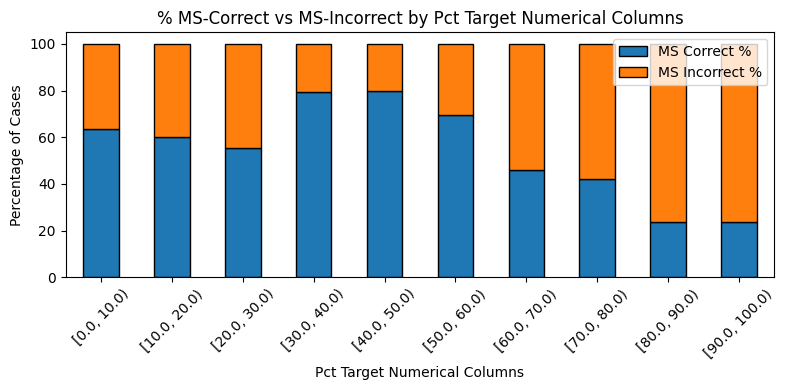

/tmp/ipykernel_1170781/3476270873.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = tmp.groupby("bin")["Correct - Multistep"].agg(total="count", correct="sum")


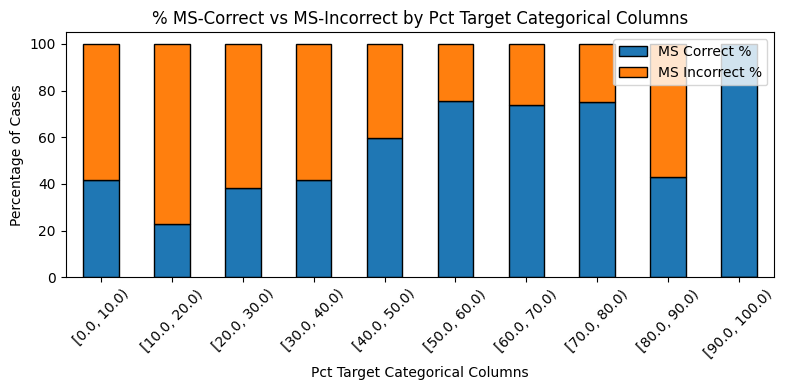

/tmp/ipykernel_1170781/3476270873.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = tmp.groupby("bin")["Correct - Multistep"].agg(total="count", correct="sum")


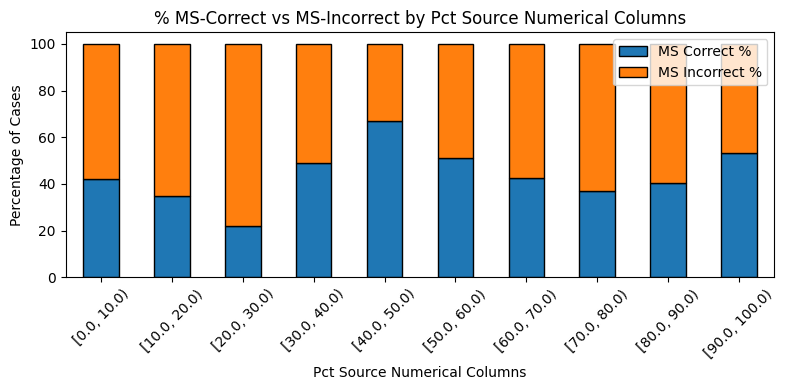

/tmp/ipykernel_1170781/3476270873.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = tmp.groupby("bin")["Correct - Multistep"].agg(total="count", correct="sum")


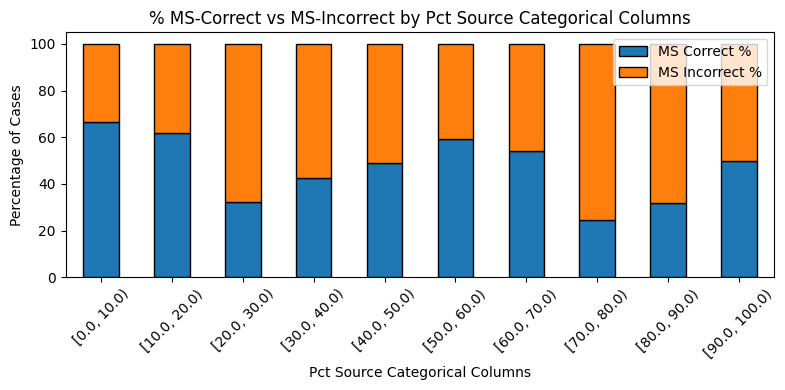

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Define which columns to plot
percent_metrics = [
    ("pct_tgt_numeric", "Pct Target Numerical Columns"),
    ("pct_tgt_categorical", "Pct Target Categorical Columns"),
    ("pct_src_numeric", "Pct Source Numerical Columns"),
    ("pct_src_categorical", "Pct Source Categorical Columns"),
]

# Create 10 equally-sized bins from 0 to 100
bins = np.linspace(0, 100, 11)

for col, label in percent_metrics:
    # Filter out any NaNs
    tmp = df[df[col].notna()].copy()
    # Bin each value
    tmp["bin"] = pd.cut(tmp[col], bins=bins, include_lowest=True, right=False)

    # For each bin, count total cases and sum of MS-Correct (1’s)
    stats = tmp.groupby("bin")["Correct - Multistep"].agg(total="count", correct="sum")
    # Compute percentages
    stats["MS Correct %"] = stats["correct"] / stats["total"] * 100
    stats["MS Incorrect %"] = 100 - stats["MS Correct %"]

    # Plot stacked bars
    ax = stats[["MS Correct %", "MS Incorrect %"]].plot(
        kind="bar", stacked=True, figsize=(8, 4), rot=45, edgecolor="k"
    )
    ax.set_xlabel(label)
    ax.set_ylabel("Percentage of Cases")
    ax.set_title(f"% MS-Correct vs MS-Incorrect by {label}")
    plt.legend(loc="upper right", frameon=True)
    plt.tight_layout()
    plt.show()